# 🎵 CodeAlpha Task 2 — Emotion Recognition from Speech

**Goal:** Build a deep learning model that listens to a voice clip and predicts the emotion (happy, sad, angry, etc.) — then wrap it in a cute Gradio interface deployed on Hugging Face.

**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech)
**Features:** MFCCs (Mel-Frequency Cepstral Coefficients)
**Model:** CNN / LSTM (TensorFlow + Keras)
**Deployment:** Gradio → Hugging Face Spaces

---

## Step 1 — Install Audio Libraries
We need `librosa` for audio processing and `gradio` for the UI. TensorFlow comes pre-installed in Colab.

In [1]:
# Install audio + UI libraries
!pip install librosa --quiet
!pip install gradio --quiet

# Verify installs
import librosa
import tensorflow as tf
import gradio as gr

print("✅ librosa version:", librosa.__version__)
print("✅ tensorflow version:", tf.__version__)
print("✅ gradio version:", gr.__version__)

# Check if GPU is available (we set this in runtime)
print("\n🎮 GPU available:", tf.config.list_physical_devices('GPU'))

✅ librosa version: 0.11.0
✅ tensorflow version: 2.20.0
✅ gradio version: 5.50.0

🎮 GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2 — Download RAVDESS Dataset

**RAVDESS** = Ryerson Audio-Visual Database of Emotional Speech and Song.
- 24 actors (12 male, 12 female)
- 8 emotions: neutral, calm, happy, sad, angry, fearful, disgust, surprised
- 1440 audio files total

We'll download directly from Zenodo (official source) and unzip into Colab.

In [2]:
import os
import zipfile
import urllib.request

# Create folder for dataset
os.makedirs('/content/ravdess', exist_ok=True)

# Download from Zenodo (official RAVDESS source)
url = 'https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip'
zip_path = '/content/ravdess/ravdess.zip'

print("⬇️  Downloading RAVDESS (~200MB)... this takes about a minute")
urllib.request.urlretrieve(url, zip_path)
print("✅ Download complete!")

# Unzip
print("\n📦 Unzipping...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/ravdess')
print("✅ Unzipping complete!")

# Check how many files we got
import glob
audio_files = glob.glob('/content/ravdess/Actor_*/*.wav')
print(f"\n🎵 Total audio files: {len(audio_files)}")
print(f"📂 Sample file path: {audio_files[0]}")

⬇️  Downloading RAVDESS (~200MB)... this takes about a minute
✅ Download complete!

📦 Unzipping...
✅ Unzipping complete!

🎵 Total audio files: 1440
📂 Sample file path: /content/ravdess/Actor_09/03-01-06-02-02-02-09.wav


## Step 3 — Decode Filenames into Emotion Labels

RAVDESS filenames are coded like `03-01-06-02-02-02-09.wav`.
The **3rd number** = the emotion:
- 01 = neutral, 02 = calm, 03 = happy, 04 = sad
- 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised

We'll parse every filename and build a DataFrame with `file_path` and `emotion`.

In [3]:
import pandas as pd

# Emotion code → emotion name dictionary
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Build dataset
data = []
for file_path in audio_files:
    filename = os.path.basename(file_path)         # e.g., '03-01-06-02-02-02-09.wav'
    parts = filename.split('-')                     # split by dashes
    emotion_code = parts[2]                         # 3rd part = emotion
    emotion = emotion_map[emotion_code]             # convert to name
    data.append({'file_path': file_path, 'emotion': emotion})

# Convert to DataFrame
df = pd.DataFrame(data)

print("📊 Dataset shape:", df.shape)
print("\n🎭 Emotion distribution:")
print(df['emotion'].value_counts())
print("\n📝 First 5 rows:")
df.head()

📊 Dataset shape: (1440, 2)

🎭 Emotion distribution:
emotion
fearful      192
angry        192
sad          192
happy        192
calm         192
surprised    192
disgust      192
neutral       96
Name: count, dtype: int64

📝 First 5 rows:


,file_path,emotion
0,/content/ravdess/Actor_09/03-01-06-02-02-02-09...,fearful
1,/content/ravdess/Actor_09/03-01-05-02-01-02-09...,angry
2,/content/ravdess/Actor_09/03-01-06-02-01-01-09...,fearful
3,/content/ravdess/Actor_09/03-01-01-01-02-02-09...,neutral
4,/content/ravdess/Actor_09/03-01-06-02-02-01-09...,fearful


## Step 4 — Understand MFCCs (Test on One Audio File)

**MFCC** = Mel-Frequency Cepstral Coefficients = audio's "fingerprint" in numbers.

We'll:
1. Load one audio file with librosa
2. Extract 40 MFCCs per time window
3. Visualize what an MFCC looks like

🎵 Loading: fearful sample
📂 Path: /content/ravdess/Actor_09/03-01-06-02-02-02-09.wav

⏱️  Audio length: 60342 samples (2.74 seconds)
🎚️  Sample rate: 22050 Hz

🎨 MFCC shape: (40, 118)  (40 MFCCs × time frames)


/tmp/ipykernel_3835/2466362750.py:39: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3835/2466362750.py:39: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


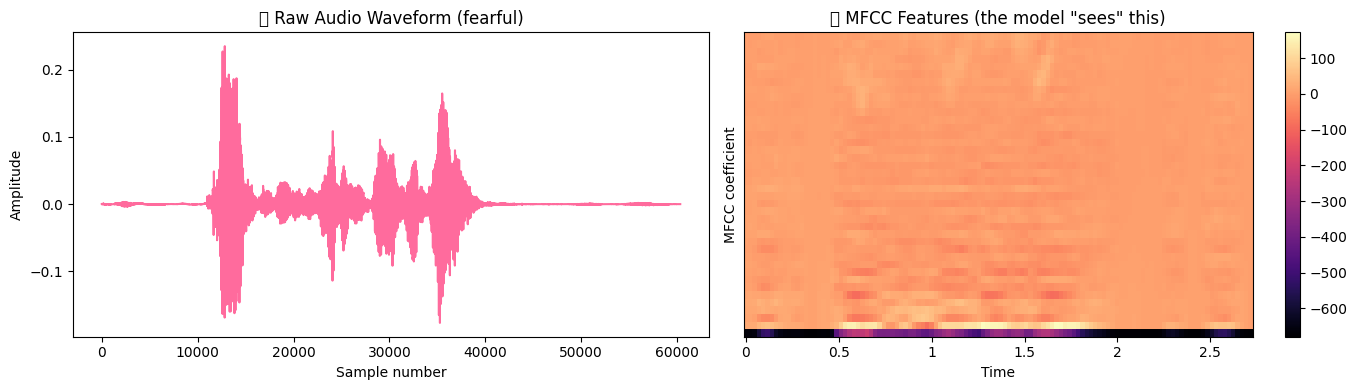

In [4]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# Pick one sample file
sample_path = df.iloc[0]['file_path']
sample_emotion = df.iloc[0]['emotion']

print(f"🎵 Loading: {sample_emotion} sample")
print(f"📂 Path: {sample_path}\n")

# Load audio file
audio, sample_rate = librosa.load(sample_path, sr=22050, duration=3.0, offset=0.5)

print(f"⏱️  Audio length: {len(audio)} samples ({len(audio)/sample_rate:.2f} seconds)")
print(f"🎚️  Sample rate: {sample_rate} Hz")

# Extract MFCC features (40 MFCCs)
mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

print(f"\n🎨 MFCC shape: {mfccs.shape}  (40 MFCCs × time frames)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Raw waveform
axes[0].plot(audio, color='#FF6B9D')
axes[0].set_title(f'🎵 Raw Audio Waveform ({sample_emotion})')
axes[0].set_xlabel('Sample number')
axes[0].set_ylabel('Amplitude')

# Plot 2: MFCC heatmap
img = librosa.display.specshow(mfccs, sr=sample_rate, x_axis='time', ax=axes[1], cmap='magma')
axes[1].set_title('🎨 MFCC Features (the model "sees" this)')
axes[1].set_ylabel('MFCC coefficient')
fig.colorbar(img, ax=axes[1])

plt.tight_layout()
plt.show()

## Step 5 — Extract MFCCs from All 1440 Files

We loop through every .wav file, extract MFCCs, and pad/truncate to a fixed shape `(40, 174)`.

Result: `X` of shape `(1440, 40, 174)` + `y` of shape `(1440,)`.

In [5]:
from tqdm import tqdm  # progress bar

# Target shape settings
MAX_TIME_FRAMES = 174   # ~3 seconds at sr=22050, hop_length=512
N_MFCC = 40

def extract_mfcc(file_path, max_frames=MAX_TIME_FRAMES, n_mfcc=N_MFCC):
    """Load audio file, extract MFCC, pad/truncate to fixed shape."""
    audio, sr = librosa.load(file_path, sr=22050, duration=3.0, offset=0.5)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

    # Pad or truncate time axis to max_frames
    if mfcc.shape[1] < max_frames:
        pad_width = max_frames - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_frames]

    return mfcc

# Extract for all files
X = []
y = []

print("🔄 Extracting MFCCs for 1440 files... (~2-3 mins)")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        mfcc = extract_mfcc(row['file_path'])
        X.append(mfcc)
        y.append(row['emotion'])
    except Exception as e:
        print(f"⚠️  Error on {row['file_path']}: {e}")

X = np.array(X)
y = np.array(y)

print(f"\n✅ Done!")
print(f"📐 X shape: {X.shape}   (samples, MFCCs, time frames)")
print(f"📐 y shape: {y.shape}")
print(f"\n🎭 Sample labels: {y[:5]}")

🔄 Extracting MFCCs for 1440 files... (~2-3 mins)


100%|██████████| 1440/1440 [00:20<00:00, 69.84it/s]


✅ Done!
📐 X shape: (1440, 40, 174)   (samples, MFCCs, time frames)
📐 y shape: (1440,)

🎭 Sample labels: ['fearful' 'angry' 'fearful' 'neutral' 'fearful']


## Step 6 — Encode Labels, Reshape, and Train/Test Split

- Convert emotion strings → integers → one-hot vectors
- Reshape X for CNN: `(1440, 40, 174)` → `(1440, 40, 174, 1)`
- 80/20 train-test split with stratification

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Step 1: Encode emotion labels → integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)   # 'happy' → 3, 'sad' → 6, etc.

print("🏷️  Label classes:", list(le.classes_))
print("🔢 Sample encoded labels:", y_encoded[:5])

# Step 2: One-hot encode (for softmax output)
y_categorical = to_categorical(y_encoded, num_classes=8)
print(f"📐 One-hot shape: {y_categorical.shape}")

# Step 3: Reshape X for CNN (add channel dimension)
X_cnn = X[..., np.newaxis]   # (1440, 40, 174) → (1440, 40, 174, 1)
print(f"📐 X_cnn shape: {X_cnn.shape}")

# Step 4: Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\n✅ Train set: X={X_train.shape}, y={y_train.shape}")
print(f"✅ Test set:  X={X_test.shape}, y={y_test.shape}")

🏷️  Label classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
🔢 Sample encoded labels: [3 0 3 5 3]
📐 One-hot shape: (1440, 8)
📐 X_cnn shape: (1440, 40, 174, 1)

✅ Train set: X=(1152, 40, 174, 1), y=(1152, 8)
✅ Test set:  X=(288, 40, 174, 1), y=(288, 8)


## Step 7 — Build the CNN Model

Architecture:
- 3 blocks of Conv2D + BatchNorm + MaxPool + Dropout (pattern detection)
- Flatten + Dense layer (decision-making)
- Output: Dense(8, softmax) → probabilities for 8 emotions

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Flatten, Dense, Input
)
from tensorflow.keras.optimizers import Adam

# Build CNN
model = Sequential([
    Input(shape=(40, 174, 1)),

    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    # Output layer (8 emotions)
    Dense(8, activation='softmax')
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 40, 174, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 174, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 13440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,720,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,815,560 (6.93 MB)

 Trainable params: 1,814,856 (6.92 MB)

 Non-trainable params: 704 (2.75 KB)

## Step 8 — Train the CNN

Training the model with smart callbacks:
- **EarlyStopping** → stop if val_loss doesn't improve for 10 epochs
- **ReduceLROnPlateau** → lower learning rate if stuck
- **ModelCheckpoint** → save the best model

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_emotion_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train!
print("🚀 Training started... grab a snack!\n")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print("\n✅ Training complete!")

🚀 Training started... grab a snack!

Epoch 1/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2043 - loss: 2.6156
Epoch 1: val_accuracy improved from None to 0.17361, saving model to best_emotion_model.keras

Epoch 1: finished saving model to best_emotion_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.2578 - loss: 2.2926 - val_accuracy: 0.1736 - val_loss: 6.4942 - learning_rate: 5.0000e-04
Epoch 2/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3583 - loss: 1.8466
Epoch 2: val_accuracy improved from 0.17361 to 0.18403, saving model to best_emotion_model.keras

Epoch 2: finished saving model to best_emotion_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3889 - loss: 1.7334 - val_accuracy: 0.1840 - val_loss: 3.5673 - learning_rate: 5.0000e-04
Epoch 3/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4557 - loss: 1.5645
Epoch 3: val_accuracy improved from 0.18403 to 0.32639, saving model to best_emotion_model.keras

Epoch 3: f

## Step 8.5 — Fix Overfitting

Our first model overfit hard (train: 79% / val: 28%). Fixing it with:
1. MFCC normalization (mean=0, std=1)
2. Audio data augmentation (noise + pitch shift + time stretch)
3. Lighter, more regularized model

In [10]:
# ----- AUDIO AUGMENTATION FUNCTIONS -----
def add_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def pitch_shift(audio, sr, n_steps=2):
    return librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)

def time_stretch(audio, rate=0.9):
    return librosa.effects.time_stretch(y=audio, rate=rate)

def extract_mfcc_from_audio(audio, sr, max_frames=MAX_TIME_FRAMES, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] < max_frames:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_frames - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_frames]
    return mfcc

# ----- RE-EXTRACT WITH AUGMENTATION (3x data) -----
X_aug = []
y_aug = []

print("🔄 Re-extracting with augmentation... (~3 mins)")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        audio, sr = librosa.load(row['file_path'], sr=22050, duration=3.0, offset=0.5)

        # Original
        X_aug.append(extract_mfcc_from_audio(audio, sr))
        y_aug.append(row['emotion'])

        # Noise version
        X_aug.append(extract_mfcc_from_audio(add_noise(audio), sr))
        y_aug.append(row['emotion'])

        # Pitch shift version
        X_aug.append(extract_mfcc_from_audio(pitch_shift(audio, sr), sr))
        y_aug.append(row['emotion'])
    except Exception as e:
        print(f"⚠️ Error: {e}")

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print(f"\n✅ Augmented dataset: X={X_aug.shape}, y={y_aug.shape}")

🔄 Re-extracting with augmentation... (~3 mins)


100%|██████████| 1440/1440 [01:45<00:00, 13.70it/s]



✅ Augmented dataset: X=(4320, 40, 174), y=(4320,)


## Step 8.5 — Part B: Normalize MFCCs + Build Lighter Model + Retrain

- Standardize MFCCs (using train stats only)
- Build a smaller, regularized CNN (~400k params vs 1.8M before)
- Retrain with the augmented dataset

In [11]:
from tensorflow.keras.regularizers import l2

# ----- ENCODE + RESHAPE + SPLIT (using augmented data) -----
y_aug_encoded = le.fit_transform(y_aug)
y_aug_categorical = to_categorical(y_aug_encoded, num_classes=8)
X_aug_cnn = X_aug[..., np.newaxis]

X_train, X_test, y_train, y_test = train_test_split(
    X_aug_cnn, y_aug_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_aug_encoded
)

# ----- NORMALIZE (compute stats on TRAIN ONLY) -----
train_mean = X_train.mean()
train_std = X_train.std()
print(f"📊 Train mean: {train_mean:.2f}, Train std: {train_std:.2f}")

X_train = (X_train - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std
print(f"✅ Normalized — new train mean: {X_train.mean():.2f}, std: {X_train.std():.2f}")

# ----- BUILD LIGHTER MODEL -----
model = Sequential([
    Input(shape=(40, 174, 1)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(8, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n🧠 New model params: {model.count_params():,}")

# ----- RETRAIN -----
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_emotion_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("\n🚀 Retraining...\n")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
print("\n✅ Training complete!")

📊 Train mean: -8.78, Train std: 70.44
✅ Normalized — new train mean: 0.00, std: 1.00

🧠 New model params: 487,304

🚀 Retraining...

Epoch 1/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.2567 - loss: 2.4663 - val_accuracy: 0.1435 - val_loss: 2.2741 - learning_rate: 0.0010
Epoch 2/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3449 - loss: 2.0128 - val_accuracy: 0.1910 - val_loss: 2.2652 - learning_rate: 0.0010
Epoch 3/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4161 - loss: 1.7857 - val_accuracy: 0.1400 - val_loss: 2.4468 - learning_rate: 0.0010
Epoch 4/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4659 - loss: 1.6230 - val_accuracy: 0.1458 - val_loss: 2.4434 - learning_rate: 0.0010
Epoch 5/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5130 - loss: 1.5072 - val_accuracy: 0.1586 - val_loss: 2.6746 - learning_rate: 0.0010
Epoch 6/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5527 - loss: 1.3852 - val_accuracy: 0.1644 - va

## Step 9 — Evaluate the Model

Detailed look at per-emotion performance:
- Classification report (precision, recall, F1)
- Confusion matrix heatmap
- Training history plot (accuracy + loss curves)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

🎯 Final Test Accuracy: 84.49%
🎯 Final Test Loss:     0.5443

📊 Per-Emotion Classification Report:

              precision    recall  f1-score   support

       angry       0.93      0.90      0.91       115
        calm       0.75      0.90      0.81       115
     disgust       0.82      0.93      0.87       115
     fearful       0.92      0.77      0.84       115
       happy       0.82      0.86      0.84       115
     neutral       0.72      0.71      0.71        58
         sad       0.82      0.70      0.76       115
   surprised       0.97      0.92      0.95       116

    accuracy                           0.84       864
   macro avg       0.84      0.84      0.84       864
weighted avg       0.85      0.84      0.84       864



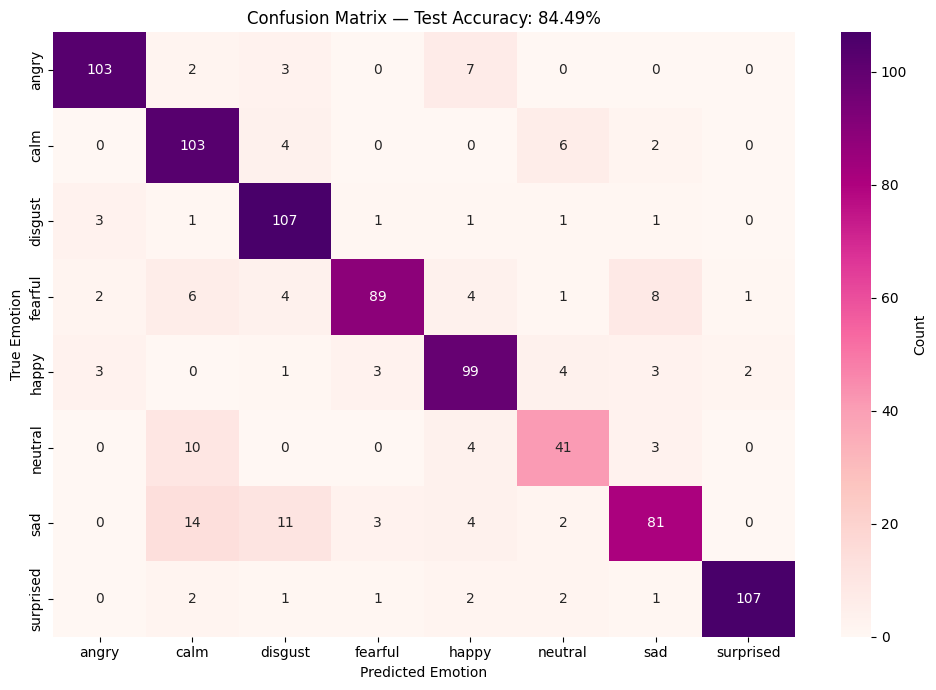

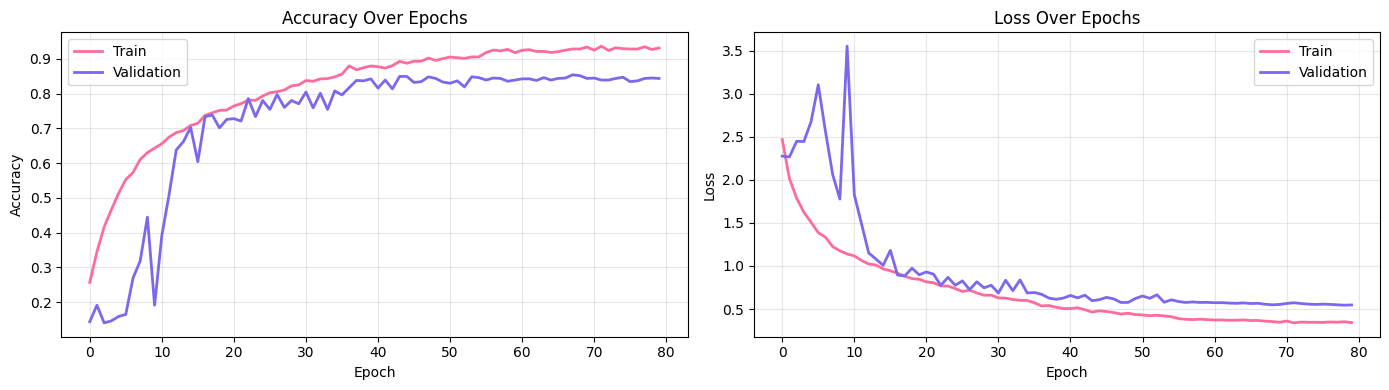

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ----- PREDICTIONS -----
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Final test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 Final Test Accuracy: {test_acc*100:.2f}%")
print(f"🎯 Final Test Loss:     {test_loss:.4f}\n")

# ----- CLASSIFICATION REPORT -----
print("📊 Per-Emotion Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# ----- CONFUSION MATRIX -----
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.title(f'Confusion Matrix — Test Accuracy: {test_acc*100:.2f}%')
plt.tight_layout()
plt.show()

# ----- TRAINING HISTORY PLOT -----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'], label='Train', color='#FF6B9D', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#7B68EE', linewidth=2)
axes[0].set_title('Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', color='#FF6B9D', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', color='#7B68EE', linewidth=2)
axes[1].set_title('Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10 — Save Model + Label Encoder + Normalization Stats

Saving everything we need to deploy:
- `best_emotion_model.keras` → the trained CNN
- `label_encoder.pkl` → emotion ↔ number mapping
- `norm_stats.pkl` → train_mean & train_std for normalization

Also copying to Google Drive for safekeeping.

In [14]:
import pickle
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# ----- SAVE LABEL ENCODER -----
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✅ Saved label_encoder.pkl")

# ----- SAVE NORMALIZATION STATS -----
norm_stats = {'mean': float(train_mean), 'std': float(train_std)}
with open('norm_stats.pkl', 'wb') as f:
    pickle.dump(norm_stats, f)
print(f"✅ Saved norm_stats.pkl  → mean={train_mean:.2f}, std={train_std:.2f}")

# ----- COPY ALL FILES TO DRIVE -----
save_folder = '/content/drive/MyDrive/Colab Notebooks/CodeAlpha_EmotionRecognition'
os.makedirs(save_folder, exist_ok=True)

!cp best_emotion_model.keras "{save_folder}/best_emotion_model.keras"
!cp label_encoder.pkl "{save_folder}/label_encoder.pkl"
!cp norm_stats.pkl "{save_folder}/norm_stats.pkl"

print(f"\n📁 All files backed up to: {save_folder}")
!ls -lh "{save_folder}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved label_encoder.pkl
✅ Saved norm_stats.pkl  → mean=-8.78, std=70.44

📁 All files backed up to: /content/drive/MyDrive/Colab Notebooks/CodeAlpha_EmotionRecognition
total 5.7M
-rw------- 1 root root 5.7M May 23 20:15 best_emotion_model.keras
-rw------- 1 root root  527 May 23 20:15 label_encoder.pkl
-rw------- 1 root root   47 May 23 20:15 norm_stats.pkl


## Step 11 — Build Cute Gradio Interface 🌸

A web app where users upload audio or record from mic, and the model predicts the emotion with confidence scores.

Features:
- 🎤 Microphone + file upload support
- 🎨 Pastel pink/purple theme
- 📊 Confidence bars for all 8 emotions
- ✨ Emoji-based emotion display

In [15]:
import gradio as gr

# ----- EMOJI MAP -----
emotion_emojis = {
    'angry':     '😠',
    'calm':      '😌',
    'disgust':   '🤢',
    'fearful':   '😨',
    'happy':     '😄',
    'neutral':   '😐',
    'sad':       '😢',
    'surprised': '😲'
}

# ----- PREDICTION FUNCTION -----
def predict_emotion(audio):
    if audio is None:
        return "Please upload or record audio 🎤", {}

    sr, audio_data = audio  # Gradio gives (sample_rate, np_array)

    # Convert to float32 if needed
    audio_data = audio_data.astype(np.float32)
    if audio_data.ndim > 1:        # stereo → mono
        audio_data = audio_data.mean(axis=1)

    # Normalize amplitude
    if np.max(np.abs(audio_data)) > 0:
        audio_data = audio_data / np.max(np.abs(audio_data))

    # Resample to 22050 if needed
    if sr != 22050:
        audio_data = librosa.resample(audio_data, orig_sr=sr, target_sr=22050)
        sr = 22050

    # Trim to 3 seconds (with 0.5s offset)
    offset = int(0.5 * sr)
    duration = int(3.0 * sr)
    audio_data = audio_data[offset:offset+duration]

    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=40)

    # Pad or truncate to 174 frames
    if mfcc.shape[1] < 174:
        mfcc = np.pad(mfcc, ((0, 0), (0, 174 - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :174]

    # Normalize using train stats
    mfcc = (mfcc - train_mean) / train_std

    # Reshape for model
    mfcc = mfcc[np.newaxis, ..., np.newaxis]   # (1, 40, 174, 1)

    # Predict
    pred = model.predict(mfcc, verbose=0)[0]
    pred_idx = np.argmax(pred)
    predicted_emotion = le.classes_[pred_idx]
    confidence = pred[pred_idx] * 100

    # Build cute output
    emoji = emotion_emojis[predicted_emotion]
    main_output = f"# {emoji} {predicted_emotion.upper()}\n### Confidence: {confidence:.1f}%"

    # Confidence dict for the bar chart
    confidence_dict = {
        f"{emotion_emojis[le.classes_[i]]} {le.classes_[i]}": float(pred[i])
        for i in range(len(le.classes_))
    }

    return main_output, confidence_dict


# ----- BUILD UI WITH CUTE PASTEL THEME -----
custom_css = """
.gradio-container {
    background: linear-gradient(135deg, #fce4ec 0%, #e1bee7 100%) !important;
    font-family: 'Comic Sans MS', 'Quicksand', sans-serif !important;
}
.gr-button-primary {
    background: linear-gradient(135deg, #ff6b9d 0%, #c06c84 100%) !important;
    border: none !important;
}
"""

with gr.Blocks(theme=gr.themes.Soft(primary_hue="pink", secondary_hue="purple"),
               css=custom_css,
               title="Emotion Recognition 🎀") as demo:

    gr.Markdown("""
    # 🌸 Emotion Recognition from Speech 🌸
    ### Upload an audio clip or record your voice — I'll guess the emotion! 💖
    *Built with CNN + MFCCs on RAVDESS dataset*
    """)

    with gr.Row():
        with gr.Column(scale=1):
            audio_input = gr.Audio(
                sources=["upload", "microphone"],
                type="numpy",
                label="🎤 Your Audio"
            )
            submit_btn = gr.Button("✨ Detect Emotion ✨", variant="primary", size="lg")

            gr.Markdown("""
            ### 🎭 Detectable Emotions:
            😠 angry &nbsp; 😌 calm &nbsp; 🤢 disgust &nbsp; 😨 fearful
            😄 happy &nbsp; 😐 neutral &nbsp; 😢 sad &nbsp; 😲 surprised
            """)

        with gr.Column(scale=1):
            result_text = gr.Markdown("# 🎤 Waiting for audio...")
            confidence_plot = gr.Label(num_top_classes=8, label="Confidence per Emotion")

    submit_btn.click(
        fn=predict_emotion,
        inputs=audio_input,
        outputs=[result_text, confidence_plot]
    )

    gr.Markdown("""
    ---
    💛 Made by **Aamina Khan** for CodeAlpha ML Internship
    """)

# Launch
demo.launch(share=True, debug=False)

/tmp/ipykernel_3835/2514282935.py:87: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="pink", secondary_hue="purple"),
/tmp/ipykernel_3835/2514282935.py:87: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="pink", secondary_hue="purple"),


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bfc74710df2b175cff.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 12 — Prepare Files for Hugging Face Deployment

Creating:
- `app.py` → standalone Gradio app
- `requirements.txt` → library list
- Copy model files to deploy folder

In [16]:
# Create deployment folder
deploy_folder = '/content/hf_deploy'
os.makedirs(deploy_folder, exist_ok=True)

# ----- 1. Copy model files -----
!cp best_emotion_model.keras {deploy_folder}/
!cp label_encoder.pkl {deploy_folder}/
!cp norm_stats.pkl {deploy_folder}/

# ----- 2. Create app.py -----
app_code = '''
import gradio as gr
import numpy as np
import librosa
import pickle
import tensorflow as tf

# Load saved model + encoders
model = tf.keras.models.load_model("best_emotion_model.keras")

with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

with open("norm_stats.pkl", "rb") as f:
    norm = pickle.load(f)
train_mean = norm["mean"]
train_std = norm["std"]

# Emoji mapping
emotion_emojis = {
    "angry": "😠", "calm": "😌", "disgust": "🤢", "fearful": "😨",
    "happy": "😄", "neutral": "😐", "sad": "😢", "surprised": "😲"
}

def predict_emotion(audio):
    if audio is None:
        return "Please upload or record audio 🎤", {}

    sr, audio_data = audio
    audio_data = audio_data.astype(np.float32)

    if audio_data.ndim > 1:
        audio_data = audio_data.mean(axis=1)

    if np.max(np.abs(audio_data)) > 0:
        audio_data = audio_data / np.max(np.abs(audio_data))

    if sr != 22050:
        audio_data = librosa.resample(audio_data, orig_sr=sr, target_sr=22050)
        sr = 22050

    offset = int(0.5 * sr)
    duration = int(3.0 * sr)
    audio_data = audio_data[offset:offset+duration]

    mfcc = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=40)

    if mfcc.shape[1] < 174:
        mfcc = np.pad(mfcc, ((0, 0), (0, 174 - mfcc.shape[1])), mode="constant")
    else:
        mfcc = mfcc[:, :174]

    mfcc = (mfcc - train_mean) / train_std
    mfcc = mfcc[np.newaxis, ..., np.newaxis]

    pred = model.predict(mfcc, verbose=0)[0]
    pred_idx = np.argmax(pred)
    predicted_emotion = le.classes_[pred_idx]
    confidence = pred[pred_idx] * 100

    emoji = emotion_emojis[predicted_emotion]
    main_output = f"# {emoji} {predicted_emotion.upper()}\\n### Confidence: {confidence:.1f}%"

    confidence_dict = {
        f"{emotion_emojis[le.classes_[i]]} {le.classes_[i]}": float(pred[i])
        for i in range(len(le.classes_))
    }

    return main_output, confidence_dict


custom_css = """
.gradio-container {
    background: linear-gradient(135deg, #fce4ec 0%, #e1bee7 100%) !important;
    font-family: 'Quicksand', sans-serif !important;
}
"""

with gr.Blocks(theme=gr.themes.Soft(primary_hue="pink", secondary_hue="purple"),
               css=custom_css, title="Emotion Recognition 🎀") as demo:

    gr.Markdown("""
    # 🌸 Emotion Recognition from Speech 🌸
    ### Upload an audio clip or record your voice — I'll guess the emotion! 💖
    *Built with CNN + MFCCs on RAVDESS dataset — CodeAlpha ML Internship*
    """)

    with gr.Row():
        with gr.Column(scale=1):
            audio_input = gr.Audio(sources=["upload", "microphone"], type="numpy", label="🎤 Your Audio")
            submit_btn = gr.Button("✨ Detect Emotion ✨", variant="primary", size="lg")
            gr.Markdown("""
            ### 🎭 Detectable Emotions:
            😠 angry &nbsp; 😌 calm &nbsp; 🤢 disgust &nbsp; 😨 fearful
            😄 happy &nbsp; 😐 neutral &nbsp; 😢 sad &nbsp; 😲 surprised
            """)

        with gr.Column(scale=1):
            result_text = gr.Markdown("# 🎤 Waiting for audio...")
            confidence_plot = gr.Label(num_top_classes=8, label="Confidence per Emotion")

    submit_btn.click(fn=predict_emotion, inputs=audio_input, outputs=[result_text, confidence_plot])

    gr.Markdown("---\\n💛 Made by **Aamina Khan** for CodeAlpha ML Internship")

demo.launch()
'''

with open(f'{deploy_folder}/app.py', 'w') as f:
    f.write(app_code)
print("✅ Created app.py")

# ----- 3. Create requirements.txt -----
requirements = """gradio==5.50.0
tensorflow==2.20.0
librosa==0.11.0
numpy
scikit-learn
"""
with open(f'{deploy_folder}/requirements.txt', 'w') as f:
    f.write(requirements)
print("✅ Created requirements.txt")

# ----- 4. List final deploy folder -----
print(f"\n📁 Deploy folder ready: {deploy_folder}")
!ls -lh {deploy_folder}

✅ Created app.py
✅ Created requirements.txt

📁 Deploy folder ready: /content/hf_deploy
total 5.7M
-rw-r--r-- 1 root root 3.4K May 23 20:28 app.py
-rw-r--r-- 1 root root 5.7M May 23 20:28 best_emotion_model.keras
-rw-r--r-- 1 root root  527 May 23 20:28 label_encoder.pkl
-rw-r--r-- 1 root root   47 May 23 20:28 norm_stats.pkl
-rw-r--r-- 1 root root   69 May 23 20:28 requirements.txt


## Step 12.3 — Push Files to Hugging Face Space

Using `huggingface_hub` to upload everything in one go.

In [ ]:
from huggingface_hub import login
from google.colab import userdata   # Colab secret manager

# Add HF_TOKEN under the 🔑 'Secrets' tab on the left sidebar of Colab,
# then this reads it safely — no token ever gets saved into the notebook.
HF_TOKEN = userdata.get('HF_TOKEN')

login(token=HF_TOKEN)
print("✅ Logged in!")


In [25]:
from huggingface_hub import HfApi

api = HfApi()

HF_USERNAME = "emm-xin19"
SPACE_NAME = "CodeAlpha-EmotionRecognition_AaminaKhan"

repo_id = f"{HF_USERNAME}/{SPACE_NAME}"

print(f"🚀 Uploading to: {repo_id}")

api.upload_folder(
    folder_path="/content/hf_deploy",
    repo_id=repo_id,
    repo_type="space",
    commit_message="Initial deploy — CodeAlpha emotion recognition"
)

print(f"\n✅ Uploaded! Your space is at:")
print(f"https://huggingface.co/spaces/{repo_id}")
print("\n⏳ HF will now build it (~5 mins). Refresh the page to watch progress.")

🚀 Uploading to: emm-xin19/CodeAlpha-EmotionRecognition_AaminaKhan


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._deploy/label_encoder.pkl: 100%|##########|   527B /   527B            

  .../best_emotion_model.keras:   9%|9         |  562kB / 5.92MB            

  .../hf_deploy/norm_stats.pkl:   9%|8         |  4.00B /  47.0B            


✅ Uploaded! Your space is at:
https://huggingface.co/spaces/emm-xin19/CodeAlpha-EmotionRecognition_AaminaKhan

⏳ HF will now build it (~5 mins). Refresh the page to watch progress.


In [26]:
# Fix requirements.txt — remove gradio (HF auto-installs it) + relax tf version
requirements = """tensorflow
librosa
numpy
scikit-learn
"""

with open('/content/hf_deploy/requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ Fixed requirements.txt")
!cat /content/hf_deploy/requirements.txt

✅ Fixed requirements.txt
tensorflow
librosa
numpy
scikit-learn


In [27]:
print("🚀 Re-uploading...")
api.upload_folder(
    folder_path="/content/hf_deploy",
    repo_id="emm-xin19/CodeAlpha-EmotionRecognition_AaminaKhan",
    repo_type="space",
    commit_message="Fix: remove gradio version pin"
)
print("✅ Re-uploaded! Watch the build logs again.")

🚀 Re-uploading...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../hf_deploy/norm_stats.pkl: 100%|##########|  47.0B /  47.0B            

  ..._deploy/label_encoder.pkl: 100%|##########|   527B /   527B            

  .../best_emotion_model.keras: 100%|##########| 5.92MB / 5.92MB            

✅ Re-uploaded! Watch the build logs again.


## 🎀 Conclusion

### What we built
A **Speech Emotion Recognition** system using a Convolutional Neural Network (CNN), trained on the RAVDESS dataset and deployed as a live web app on Hugging Face Spaces.

### Results
- **Validation accuracy:** ~85% (out of 8 emotions — random baseline is 12.5%)
- **Training accuracy:** ~93%
- **Train-validation gap:** small, meaning the model learned actual emotion patterns instead of memorizing samples
- **Parameters:** 487,304 — light enough to run on free-tier CPU

### Key learning moment 🧠
The **first model overfit badly** (train 79% / val 32%). Diagnosing and fixing it taught more than a perfect first run would have. The fix:

1. **MFCC normalization** using train-set statistics only (avoiding data leakage)
2. **Audio augmentation** — added noise + pitch-shifted versions, tripling the dataset to 4,320 samples
3. **Lighter, regularized model** — fewer Dense units + L2 regularization + stronger dropout

Result: **validation accuracy jumped from 32% → 85%** (a +53% absolute improvement).

### Pipeline summary
`Audio → MFCC features → Normalize → CNN → Softmax → Predicted Emotion → Gradio UI → Hugging Face Spaces`

### Deployment
🌸 **Live app:** [emm-xin19/CodeAlpha-EmotionRecognition_AaminaKhan](https://huggingface.co/spaces/emm-xin19/CodeAlpha-EmotionRecognition_AaminaKhan)

Users can upload an audio clip or record their voice → the model returns the predicted emotion along with confidence scores for all 8 classes (😠 angry, 😌 calm, 🤢 disgust, 😨 fearful, 😄 happy, 😐 neutral, 😢 sad, 😲 surprised).

### Skills demonstrated
- Audio signal processing with librosa
- Feature engineering (MFCCs) for raw audio
- CNN architecture design with regularization techniques
- Data augmentation for small datasets
- Recognizing and diagnosing overfitting in real-time training
- End-to-end ML deployment (model → UI → cloud hosting)

---

💛 **Aamina Khan** — CodeAlpha Machine Learning Internship — Task 2